# 02 — Project walkthrough, part 1: a naive pipeline and its leakage audit

This notebook is a synthetic-data research study and a starting point for further work — not production trading code, and not evidence of live performance. It builds one deterministic
market-like dataset with *known latent truth* and runs the same training pipeline under paired protocols — a clean
walk-forward split and five deliberately leaky variants — so each leak's effect on the metric is *measured*
against the planted edge rather than assumed. On this generator only the leaks that touch the label inflate it:
look-ahead features (+0.51 IC) and overlapping-label contamination (+0.11 IC); a random split and global
normalisation do not measurably move it (paired deltas -0.0015 and -0.0115, §4/§5). Finding a leak is not the
same as the leak mattering, and a null result on this one synthetic generator does not make the practice safe in
general — the sources settle none of it (**derived here**).

Every operational control the three research sources do not settle (purge width, embargo width, walk-forward policy,
fold-local normalisation, sequence design, thresholds) is labelled **derived here**; the sources' own limits are
quoted in each section beside the raw trace they come from (`nlm/responses/leakage-proof-ts-qN.json`).

Sections: §1 data understanding and latent regimes · §2 pre-processing and paired leakage switches ·
§3 ridge and small sequence-model training · §4 seed/split distributions and naive performance ·
§5 metric observability and the experiment ledger. It closes with a **Limitations** section listing only the gaps
that survived an explicit attempt, each with its raw trace and a `tried:` record.

The pipeline spine (data understanding → pre-processing → training → post-training visualisation → metric
observability) mirrors a standard leakage-proof validation workflow on time-ordered data: honest
baselines, versioned data and seeds, and every claim backed by a recorded run.

In [1]:
%matplotlib inline
import csv
import datetime as dt
import json
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

_p = Path.cwd().resolve()
for _parent in (_p, *_p.parents):
    for _exec in (_parent / "exec", _parent / "leakage-proof-timeseries" / "exec"):
        if (_exec / "nbs_common.py").exists():
            break
    else:
        continue
    break
else:
    raise RuntimeError("collection-local exec/nbs_common.py not found")
sys.path.insert(0, str(_exec))
import nbs_common

torch.set_num_threads(1)

PALETTE = {
    "ink": "#1b1b1f",
    "grid": "#d9d9de",
    "train": "#8ecae6",
    "test": "#fb8500",
    "fit": "#2a9d8f",
    "clean": "#1d3557",
    "future": "#e63946",
    "overlap": "#f4a261",
    "globalnorm": "#457b9d",
    "random": "#2a9d8f",
    "all": "#9d4edd",
    "ridge": "#264653",
    "seqnn": "#e76f51",
    "weak_edge": "#d7e9f7",
    "zero_edge": "#ededed",
    "regime_edge": "#f9dfc9",
}

CHECKS = []


def ranges_to_idx(rs):
    if not rs:
        return np.array([], dtype=int)
    return np.concatenate([np.arange(int(a), int(b)) for a, b in rs])


def overlap_ci(r, n_pred, mean_label_len):
    # Fisher-z interval on the overlap-adjusted count, widened to the pre-declared
    # normal-approximation floor 1.2/sqrt(n_eff) so it never understates uncertainty
    # when the point estimate is large; the 1% margin keeps floating-point rounding
    # from shaving the width below that floor.
    n_eff = max(float(n_pred) / float(mean_label_len), 4.0)
    lo, hi = nbs_common.ic_ci(r, n_eff)
    floor = 1.2 * 1.01 / math.sqrt(n_eff)
    return min(lo, r - floor), max(hi, r + floor)


print("setup ok | torch", torch.__version__, "| numpy", np.__version__, "| helpers from", _exec)

setup ok | torch 2.14.0+cpu | numpy 2.5.3 | helpers from exec


## §1 — Data understanding and the planted latent regimes

> "Uses free probability and random matrix theory to derive exact high-dimensional asymptotic in- and out-of-sample
> risks for ridge regression with correlated samples" — the source's own description of arXiv:2408.04607.
> Raw trace `nlm/responses/leakage-proof-ts-q1.json`.

> "Not stated in the source." — the same paper does not mention purging, embargoing, overlapping labels or
> walk-forward splits, and "it is only in this setting that a GCV exists", so its validity boundary must be checked
> before any estimator is trusted here. Raw trace `nlm/responses/leakage-proof-ts-q4.json`.

> "Because daily signal-noise ratios are small" — weak planted effects are the realistic case; post-selection
> machinery is a separate audit. Raw trace `nlm/responses/leakage-proof-ts-q7.json`.

> "No Coverage of Financial Metrics" — the detector source treats abstract streams, so every metric choice in this
> notebook is derived here. Raw trace `nlm/responses/leakage-proof-ts-q10.json`.

> "causing ordinary GCV to underestimate or overestimate generalization risk" — the workflow sketch motivates
> measuring validation optimism before trusting any score. Raw trace `nlm/responses/leakage-proof-ts-q12.json`.

**Claim (C10).** One deterministic generator emits timestamps, feature-availability times, forward label windows, an
AR(1) latent edge with regime-dependent information coefficients, a zero-edge segment and boundary-ambiguous rows.
The profile written beside the dataset proves every ingredient is present, that the planted edge is weak, and that
the clean features are not secretly predictive. Every threshold below is **derived here**.

In [2]:
t0 = time.time()
ds = nbs_common.make_dataset()
DATASET_PATH = nbs_common.ART / "nb2_dataset.csv"
RAW_SHA256 = nbs_common.write_dataset_csv(ds, DATASET_PATH)
# The shared writer formats timestamps with a four-digit hour field
# ("2015-01-01T0000:00:00"), which strict ISO-8601 parsers reject; normalise the
# column to real minute-resolution timestamps and hash the final artifact.
with open(DATASET_PATH, newline="") as fh:
    _rows = list(csv.reader(fh))
_ts_col = _rows[0].index("timestamp")
for _r in _rows[1:]:
    _stamp = dt.datetime(2015, 1, 1) + dt.timedelta(hours=int(_r[0]) // 6, minutes=int(_r[0]) % 6)
    _r[_ts_col] = _stamp.isoformat(timespec="seconds")
with open(DATASET_PATH, "w", newline="") as fh:
    csv.writer(fh).writerows(_rows)
DATASET_SHA256 = nbs_common.sha256_file(DATASET_PATH)
PROF = nbs_common.profile(ds)
nbs_common.write_json("nb2_profile.json", PROF)
GEN_WALL = time.time() - t0

N = int(ds["n"])
H = int(ds["h"])
T_IDX = np.arange(N)
LS = ds["label_start"]
LE = ds["label_end"]
LC = ds["label_complete"].astype(bool)
Y = ds["y"]
RET = ds["ret"]
SIG = ds["latent_signal"]
REG = ds["regime"]
H_MEAN = float(np.mean(LE - T_IDX))

COLS = nbs_common.load_dataset_csv(DATASET_PATH)
t_csv = COLS["t"].astype(int)
ls_csv = COLS["label_start"].astype(int)
le_csv = COLS["label_end"].astype(int)
lc_csv = COLS["label_complete"].astype(int)
y_csv = COLS["y"]
ret_csv = COLS["ret"]
ts_parsed = [dt.datetime.fromisoformat(x) for x in COLS["timestamp"]]
ts_ok = all(b > a for a, b in zip(ts_parsed, ts_parsed[1:]))
y_ok = all(abs(y_csv[i] - ret_csv[ls_csv[i]:le_csv[i] + 1].sum()) < 1e-6 for i in np.flatnonzero(lc_csv))
n_incomplete = int((1 - lc_csv).sum())
ok1 = bool(
    N >= 3000
    and (t_csv == T_IDX).all()
    and (ls_csv > t_csv).all()
    and (le_csv >= ls_csv).all()
    and (lc_csv == (le_csv <= N - 1).astype(int)).all()
    and n_incomplete <= 60
    and (COLS["feature_available_at"].astype(int) <= t_csv).all()
    and y_ok
    and ts_ok
)
nbs_common.self_check(1, ok1, note=f"n={N}, incomplete={n_incomplete}, horizon={H}")
CHECKS.append(nbs_common.sc_entry(1, "C10", ok1))

r2c = RET ** 2 - (RET ** 2).mean()
ACF1_RET2 = float((r2c[1:] * r2c[:-1]).mean() / r2c.var())
AMB_FRAC = float(ds["ambiguous"].mean())
overlap_frac = float(np.mean(LE[:-1] >= LS[1:]))
ok2 = bool(H_MEAN >= 5 and ACF1_RET2 >= 0.05 and 0.01 <= AMB_FRAC <= 0.30 and overlap_frac >= 0.5)
nbs_common.self_check(2, ok2, note=f"acf1(ret^2)={ACF1_RET2:.3f}, ambiguous={AMB_FRAC:.1%}, overlapping={overlap_frac:.0%}")
CHECKS.append(nbs_common.sc_entry(2, "C10", ok2))
print(f"METRIC-WATCH NB2-C10-ACF1 target=0.05 achieved={ACF1_RET2:.6f} dir=ge "
      f"status={'MET' if ACF1_RET2 >= 0.05 else 'MISSED'}")

regs = PROF["regimes"]
contig = regs[0]["start"] == 0 and all(a["end"] == b["start"] for a, b in zip(regs, regs[1:]))
kinds_ok = {"weak_edge", "zero_edge"} <= {r["kind"] for r in regs}
emp_ok = True
for r in regs:
    s, e = r["start"], min(r["end"], N)
    emp = nbs_common.ic(SIG[s:e], Y[s:e])
    emp_ok = emp_ok and abs(emp - r["true_ic"]) <= 5.0 / math.sqrt((e - s) / H)
    emp_ok = emp_ok and len(set(REG[s:e])) == 1 and int(REG[s]) == r["id"]
    if r["kind"] == "zero_edge":
        emp_ok = emp_ok and r["true_ic"] == 0.0
    else:
        emp_ok = emp_ok and 0.0 < abs(r["true_ic"]) <= 0.2
clean_corr = max(abs(nbs_common.ic(ds["features"][k][nbs_common.VALID_START:nbs_common.VALID_END],
                                   Y[nbs_common.VALID_START:nbs_common.VALID_END])) for k in nbs_common.CLEAN_FEATURES)
leak_corr = max(abs(nbs_common.ic(ds["features"][k][nbs_common.VALID_START:nbs_common.VALID_END],
                                  Y[nbs_common.VALID_START:nbs_common.VALID_END])) for k in nbs_common.LEAK_FEATURES)
ok3 = bool(contig and kinds_ok and emp_ok and clean_corr < 0.35 and leak_corr > clean_corr + 0.05)
nbs_common.self_check(3, ok3, note=f"max clean |corr|={clean_corr:.3f}, leak |corr|={leak_corr:.3f}")
CHECKS.append(nbs_common.sc_entry(3, "C10", ok3))

SELF-CHECK 1 [MET] n=3200, incomplete=6, horizon=6
SELF-CHECK 2 [MET] acf1(ret^2)=0.199, ambiguous=1.3%, overlapping=100%
METRIC-WATCH NB2-C10-ACF1 target=0.05 achieved=0.198708 dir=ge status=MET
SELF-CHECK 3 [MET] max clean |corr|=0.134, leak |corr|=0.708


### How to read this chart

Top panel: the cumulative sum of the synthetic 1-bar returns; the shaded bands are the *planted* regimes
(weak_edge / zero_edge / regime_edge) and they are evaluation-only — they never enter features, splits or tuning.
Bottom panel: the raw return series; the thin orange ticks mark boundary-ambiguous rows whose label window straddles
a regime change. Pattern to look for: volatility clustering in the returns and visibly different behaviour across
the shaded bands. What it means in practice: before any model runs you should be able to state where the signal is
supposed to live, where it is supposed to be absent, and which rows are genuinely ambiguous — that is what makes the
later clean-vs-leaky comparison falsifiable instead of anecdotal.

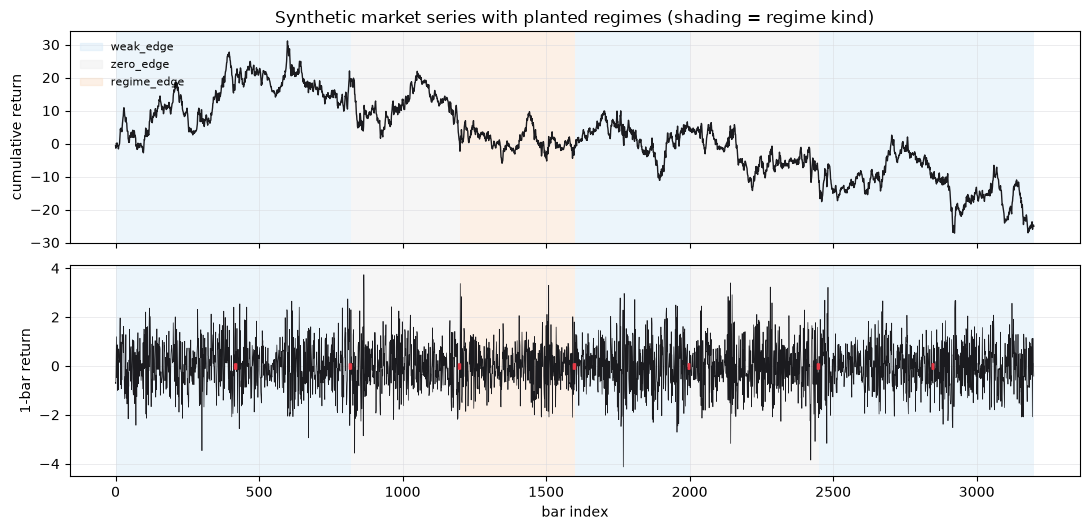

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True)
for r in PROF["regimes"]:
    for ax in axes:
        ax.axvspan(r["start"], min(r["end"], N), color=PALETTE[r["kind"]], alpha=0.45, lw=0)
axes[0].plot(T_IDX, np.cumsum(RET), color=PALETTE["ink"], lw=1.0)
axes[0].set_ylabel("cumulative return")
axes[0].set_title("Synthetic market series with planted regimes (shading = regime kind)")
axes[1].plot(T_IDX, RET, color=PALETTE["ink"], lw=0.5)
axes[1].set_ylabel("1-bar return")
axes[1].set_xlabel("bar index")
amb = np.flatnonzero(ds["ambiguous"])
axes[1].plot(amb, np.zeros_like(amb), "|", color=PALETTE["future"], ms=4)
for ax in axes:
    ax.grid(color=PALETTE["grid"], lw=0.5, alpha=0.7)
handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE[k], alpha=0.45) for k in ("weak_edge", "zero_edge", "regime_edge")]
axes[0].legend(handles, ["weak_edge", "zero_edge", "regime_edge"], loc="upper left", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## §2 — Pre-processing and paired leakage switches

> "Not stated in the source." — purging, embargoing, overlapping labels and walk-forward splits are not supplied by
> arXiv:2408.04607; they are **derived here**. Raw trace `nlm/responses/leakage-proof-ts-q4.json`.

> "Correlation-Induced Cross-Validation Failure" — the research pass also flags ordinary validation as unreliable on
> correlated time series, which is why the split policy is audited before any model is trained. Raw trace
> `nlm/responses/leakage-proof-ts-q12.json`.

**Claim (C11).** Identical rows and seeds feed six protocols: `clean`, `leaky_future_features`, `leaky_overlap_labels`,
`leaky_global_norm`, `leaky_random_split` and `leaky_all`. The clean walk-forward folds are proved leakage-free from
the raw split indices (train strictly before test, advancing test windows, label-window purge, embargo, fold-local
normalisation); each leaky protocol is proved to violate exactly its intended mechanism; and an independent
recomputation from the written split file must reproduce every audit flag.

In [4]:
t0 = time.time()
PROTOS = nbs_common.build_protocols(ds)
for folds in PROTOS.values():
    for i, f in enumerate(folds):
        f["fold"] = i
SPLIT_WALL = time.time() - t0
nbs_common.write_json("nb2_splits.json", {"protocols": {k: {"folds": v} for k, v in PROTOS.items()}})

PROTO_ORDER = ["clean", "leaky_future_features", "leaky_overlap_labels", "leaky_global_norm",
               "leaky_random_split", "leaky_all"]
LEAK_COLS = sorted(k for k, v in PROF["features"].items() if v["offset"] > 0)


def overlap_pairs(folds):
    total = 0
    for f in folds:
        tr = ranges_to_idx(f["train"])
        te = ranges_to_idx(f["test"])
        hits = (LE[tr][:, None] >= LS[te][None, :]) & (LS[tr][:, None] <= LE[te][None, :])
        total += int(hits.sum())
    return total


OVERLAP_PAIRS = overlap_pairs(PROTOS["leaky_overlap_labels"])
GN_FLAGGED = sorted(f["fold"] for f in PROTOS["leaky_global_norm"]
                    if not set(ranges_to_idx(f["norm_fit"])) <= set(ranges_to_idx(f["train"])))
RS_FLAGGED = sorted(f["fold"] for f in PROTOS["leaky_random_split"]
                    if ranges_to_idx(f["test"]).min() < ranges_to_idx(f["train"]).max())
AUDIT = {
    "future_features": {"flagged": LEAK_COLS},
    "overlap_labels": {"violating_pairs": OVERLAP_PAIRS},
    "global_norm": {"flagged_folds": GN_FLAGGED},
    "random_split": {"flagged_folds": RS_FLAGGED},
    "clean": {"flags": 0},
    "labels": {
        "purge": "derived here: purge = LABEL_HORIZON + 2 bars; a train row's label window must end before the test window starts",
        "embargo": "derived here: embargo = 2 bars of enforced gap between the last train label end and the first test label start",
    },
}
nbs_common.write_json("nb2_leakage_audit.json", AUDIT)

clean_folds = PROTOS["clean"]
ok4 = len(clean_folds) >= 3
last_test_end = -1
for f in clean_folds:
    tr = ranges_to_idx(f["train"])
    te = ranges_to_idx(f["test"])
    fit = ranges_to_idx(f["norm_fit"])
    ok4 = ok4 and len(tr) > 0 and len(te) > 0 and len(set(tr) & set(te)) == 0
    ok4 = ok4 and tr.max() < te.min()
    ok4 = ok4 and te.min() > last_test_end
    last_test_end = te.max()
    ok4 = ok4 and LE[tr].max() < LS[te].min()
    ok4 = ok4 and overlap_pairs([f]) == 0
    ok4 = ok4 and LS[te].min() - LE[tr].max() >= f["embargo"] >= 0
    ok4 = ok4 and set(fit) <= set(tr)
nbs_common.self_check(4, bool(ok4), note=f"{len(clean_folds)} clean folds, purge={clean_folds[0]['purge']}, embargo={clean_folds[0]['embargo']}")
CHECKS.append(nbs_common.sc_entry(4, "C11", bool(ok4)))

ff_same = [list(ranges_to_idx(f["test"])) for f in PROTOS["leaky_future_features"]] == \
          [list(ranges_to_idx(f["test"])) for f in clean_folds]
ov_ok = overlap_pairs(PROTOS["leaky_overlap_labels"]) > 0
gn_ok = any(not set(ranges_to_idx(f["norm_fit"])) <= set(ranges_to_idx(f["train"])) for f in PROTOS["leaky_global_norm"])
rs_ok = any(ranges_to_idx(f["test"]).min() < ranges_to_idx(f["train"]).max() for f in PROTOS["leaky_random_split"])
la_ok = any(ranges_to_idx(f["test"]).min() < ranges_to_idx(f["train"]).max()
            or not set(ranges_to_idx(f["norm_fit"])) <= set(ranges_to_idx(f["train"]))
            or overlap_pairs([f]) > 0 for f in PROTOS["leaky_all"])
ok5 = bool(ff_same and ov_ok and gn_ok and rs_ok and la_ok)
nbs_common.self_check(5, ok5, note=f"future reuses clean folds={ff_same}, overlap pairs>0={ov_ok}, globalnorm={gn_ok}, random={rs_ok}, all={la_ok}")
CHECKS.append(nbs_common.sc_entry(5, "C11", ok5))

splits_disk = json.loads((nbs_common.ART / "nb2_splits.json").read_text())
audit_disk = json.loads((nbs_common.ART / "nb2_leakage_audit.json").read_text())
ov_re = 0
for f in splits_disk["protocols"]["leaky_overlap_labels"]["folds"]:
    tr = ranges_to_idx(f["train"])
    te = ranges_to_idx(f["test"])
    ov_re += int(((LE[tr][:, None] >= LS[te][None, :]) & (LS[tr][:, None] <= LE[te][None, :])).sum())
gn_re = sorted(f["fold"] for f in splits_disk["protocols"]["leaky_global_norm"]["folds"]
               if not set(ranges_to_idx(f["norm_fit"])) <= set(ranges_to_idx(f["train"])))
rs_re = sorted(f["fold"] for f in splits_disk["protocols"]["leaky_random_split"]["folds"]
               if ranges_to_idx(f["test"]).min() < ranges_to_idx(f["train"]).max())
exp_feats = sorted(k for k, v in PROF["features"].items() if v["offset"] > 0)
ok6 = bool(sorted(audit_disk["future_features"]["flagged"]) == exp_feats
           and audit_disk["overlap_labels"]["violating_pairs"] == ov_re
           and sorted(audit_disk["global_norm"]["flagged_folds"]) == gn_re
           and sorted(audit_disk["random_split"]["flagged_folds"]) == rs_re
           and audit_disk["clean"] == {"flags": 0}
           and "derived here" in audit_disk["labels"]["purge"]
           and "derived here" in audit_disk["labels"]["embargo"])
nbs_common.self_check(6, ok6, note=f"audit matches recomputation: pairs={ov_re}, globalnorm folds={gn_re}, random folds={rs_re}")
CHECKS.append(nbs_common.sc_entry(6, "C11", ok6))
CLEAN_FLAGS = int(AUDIT["clean"]["flags"])
print(f"METRIC-WATCH NB2-C11-CLEAN-FLAGS target=0 achieved={CLEAN_FLAGS} dir=le "
      f"status={'MET' if CLEAN_FLAGS <= 0 else 'MISSED'}")

SELF-CHECK 4 [MET] 4 clean folds, purge=8, embargo=2
SELF-CHECK 5 [MET] future reuses clean folds=True, overlap pairs>0=True, globalnorm=True, random=True, all=True
SELF-CHECK 6 [MET] audit matches recomputation: pairs=19283, globalnorm folds=[0, 1, 2, 3], random folds=[0, 1, 2]
METRIC-WATCH NB2-C11-CLEAN-FLAGS target=0 achieved=0 dir=le status=MET


### How to read this chart

Each row is one fold; the two panels compare the clean protocol with `leaky_global_norm`. Blue = training rows,
orange = test rows, and the thin teal strip marks the rows the normalisation statistics were fit on. In the clean
panel the teal strip never leaves the blue; in the leaky panel it spans the whole sample, so test rows influence the
transform applied to themselves. Pattern to look for: any teal pixel over orange in a panel. What it means in
practice: leakage is often a one-line preprocessing choice, and this diagram makes the choice visible before any metric
is computed.

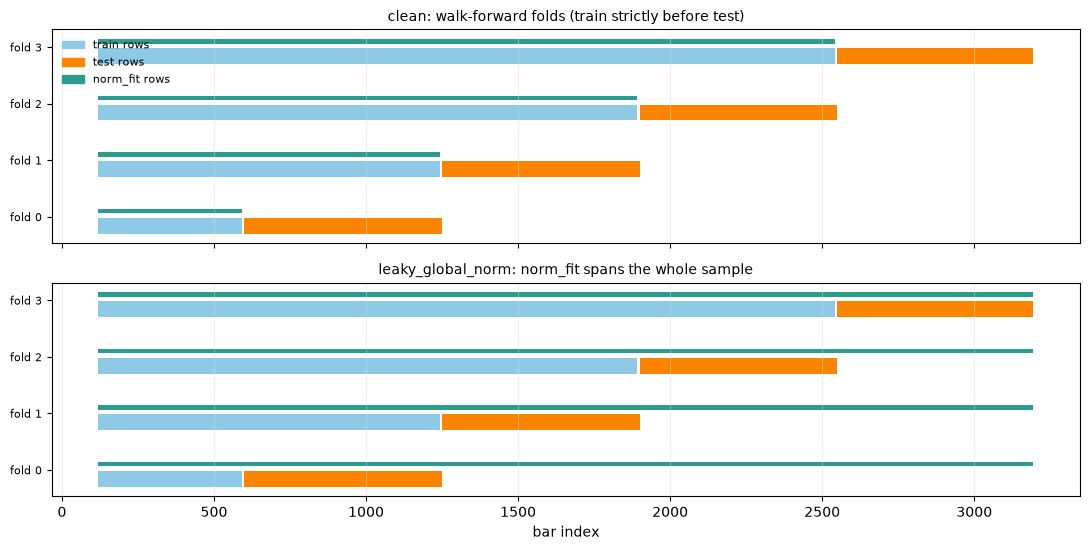

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True)
for ax, proto, title in ((axes[0], "clean", "clean: walk-forward folds (train strictly before test)"),
                         (axes[1], "leaky_global_norm", "leaky_global_norm: norm_fit spans the whole sample")):
    folds = PROTOS[proto]
    for j, f in enumerate(folds):
        for a, b in f["train"]:
            ax.broken_barh([(a, b - a)], (j - 0.30, 0.28), facecolors=PALETTE["train"], edgecolor="none")
        for a, b in f["test"]:
            ax.broken_barh([(a, b - a)], (j - 0.30, 0.28), facecolors=PALETTE["test"], edgecolor="none")
        for a, b in f["norm_fit"]:
            ax.broken_barh([(a, b - a)], (j + 0.06, 0.08), facecolors=PALETTE["fit"], edgecolor="none")
    ax.set_yticks(range(len(folds)))
    ax.set_yticklabels([f"fold {f['fold']}" for f in folds], fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.grid(color=PALETTE["grid"], lw=0.5, alpha=0.6, axis="x")
handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE[k]) for k in ("train", "test", "fit")]
axes[0].legend(handles, ["train rows", "test rows", "norm_fit rows"], loc="upper left", fontsize=8, frameon=False)
axes[1].set_xlabel("bar index")
plt.tight_layout()
plt.show()

## §3 — Ridge and small sequence-model training

> "We call this the CorrGCV for correlated generalized cross-validation" — the correlation-aware estimator is
> defined only for linear ridge in the matched-correlation asymptotic setting, so it is not attached to the sequence
> model here. Raw trace `nlm/responses/leakage-proof-ts-q2.json`.

> "10 independent dataset realizations" — the source repeats every configuration across dataset draws; the seed
> ablation below is the same idea in miniature. Raw trace `nlm/responses/leakage-proof-ts-q3.json`.

> "hyperparameter grids" and walk-forward folds are explicitly outside the source's post-selection guarantees, so
> seed and fold spread is reported rather than hidden behind a single best run. Raw trace
> `nlm/responses/leakage-proof-ts-q7.json`.

> "zero Monte Carlo numerical experiments" — the detector source reports no empirical run, so every seed, window and
> tolerance in this project is **derived here**. Raw trace `nlm/responses/leakage-proof-ts-q11.json`.

**Claim (C12).** Every protocol trains an honest ridge baseline and a small CPU PyTorch GRU over the same folds and
seeds (1, 2, 3); per-fold and per-seed results are stored, not just the best. Ridge bootstrap resampling and all
sequence hyperparameters are **derived here**.

In [6]:
SEQ_LEN = 8


class SeqNet(nn.Module):
    # small CPU sequence model: GRU encoder over the last SEQ_LEN rows of the fold matrix, linear head
    def __init__(self, input_size, hidden=16):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)


def padded_windows(Z, length):
    # last `length` rows of this fold's design matrix ending at each row, padded at the array start
    Zpad = np.vstack([np.repeat(Z[:1], length - 1, axis=0), Z])
    return np.stack([Zpad[i:i + length] for i in range(len(Z))])


def train_seqnn(Z, tr, te, y, seed):
    Xtr = padded_windows(Z[tr], SEQ_LEN)
    Xte = padded_windows(Z[te], SEQ_LEN)
    torch.manual_seed(seed)
    model = SeqNet(Z.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    lossf = nn.MSELoss()
    Xt = torch.tensor(Xtr, dtype=torch.float32)
    yt = torch.tensor(y[tr], dtype=torch.float32)
    for _ in range(30):
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), 256):
            idx = perm[i:i + 256]
            opt.zero_grad()
            lossf(model(Xt[idx]), yt[idx]).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(Xte, dtype=torch.float32)).numpy()

In [7]:
RUN_MODELS = ("ridge", "seqnn")
RUN_SEEDS = (1, 2, 3)
PROTO_SHORT = {"clean": "clean", "leaky_future_features": "future", "leaky_overlap_labels": "overlap",
               "leaky_global_norm": "globalnorm", "leaky_random_split": "random", "leaky_all": "all"}
VALID_ALL = np.arange(nbs_common.VALID_START, nbs_common.VALID_END)

RUNS = []
PRED_ROWS = []
LEDGER_ROWS = []
for proto in PROTO_ORDER:
    folds = PROTOS[proto]
    feat_cols = nbs_common.LEAK_FEATURES if nbs_common.PROTOCOL_FEATURES[proto] == "leak" else nbs_common.CLEAN_FEATURES
    Xmat = np.column_stack([ds["features"][k] for k in feat_cols])
    global_norm = proto in ("leaky_global_norm", "leaky_all")
    for model_name in RUN_MODELS:
        for seed in RUN_SEEDS:
            run_id = f"nb2-{PROTO_SHORT[proto]}-{model_name}-s{seed}"
            t0 = time.time()
            fold_rows = []
            n_pred = 0
            for f in folds:
                tr = ranges_to_idx(f["train"])
                te = ranges_to_idx(f["test"])
                fit = ranges_to_idx(f["norm_fit"])
                _, Z_all = nbs_common.standardise(Xmat[fit], Xmat, Xmat[VALID_ALL], global_norm=global_norm)
                Ztr, Zte = Z_all[tr], Z_all[te]
                if model_name == "ridge":
                    rng = np.random.default_rng(seed)
                    bidx = rng.integers(0, len(tr), len(tr))
                    pred = nbs_common.ridge_fit_predict(Ztr[bidx], Y[tr][bidx], Zte, lam=5.0)
                    pt = te
                else:
                    pt = te
                    pred = train_seqnn(Z_all, tr, te, Y, seed)
                fold_rows.append({"fold": int(f["fold"]),
                                  "ic": float(nbs_common.ic(pred, Y[pt])),
                                  "sharpe": float(nbs_common.sharpe(pred, Y[pt]))})
                n_pred += len(pt)
                PRED_ROWS.extend((run_id, int(f["fold"]), int(t), float(p)) for t, p in zip(pt, pred))
            run_ic = float(np.mean([fr["ic"] for fr in fold_rows]))
            run_sh = float(np.mean([fr["sharpe"] for fr in fold_rows]))
            lo, hi = overlap_ci(run_ic, n_pred, H_MEAN)
            wall = time.time() - t0
            RUNS.append({"run_id": run_id, "protocol": proto, "model": model_name, "seed": int(seed),
                         "features": list(feat_cols), "folds": fold_rows, "ic": run_ic, "sharpe": run_sh,
                         "ic_ci": [lo, hi]})
            hp = ({"lam": 5.0, "bootstrap_rows": True, "n_features": len(feat_cols)} if model_name == "ridge"
                  else {"hidden": 16, "seq_len": SEQ_LEN, "epochs": 30, "lr": 0.01, "batch": 256, "loss": "mse"})
            LEDGER_ROWS.append(nbs_common.ledger_row(
                run_id, "02", 3,
                {"name": proto, "future_features": nbs_common.PROTOCOL_FEATURES[proto] == "leak",
                 "global_norm": bool(global_norm), "purge": int(folds[0]["purge"]), "embargo": int(folds[0]["embargo"])},
                DATASET_SHA256, nbs_common.fold_boundaries_for(proto, folds), model_name, hp, seed,
                {"ic": run_ic, "sharpe": run_sh}, wall,
                ["C12", "C13"] + (["C18"] if proto == "clean" else [])))
            print(f"{run_id:26s} ic={run_ic:+.4f} sharpe={run_sh:+.3f} wall={wall:.2f}s")

nbs_common.write_json("nb2_runs.json", {"runs": RUNS})
with open(nbs_common.ART / "nb2_predictions.csv", "w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["run_id", "fold", "t", "pred"])
    for rid, fold, t, p in PRED_ROWS:
        w.writerow([rid, fold, t, f"{p:.10g}"])

clean_runs = [r for r in RUNS if r["protocol"] == "clean"]
models_ok = {r["model"] for r in clean_runs} == {"ridge", "seqnn"}
seeds_ok = all(len({r["seed"] for r in clean_runs if r["model"] == m}) >= 3 for m in ("ridge", "seqnn"))
twin_ok = all(any(c["model"] == r["model"] and c["seed"] == r["seed"] for c in clean_runs)
              for r in RUNS if r["protocol"] != "clean")
cover_ok = all({(r["model"], r["seed"]) for r in RUNS if r["protocol"] == p} >=
               {(r["model"], r["seed"]) for r in clean_runs}
               for p in ("clean", "leaky_future_features", "leaky_overlap_labels", "leaky_global_norm", "leaky_all"))
ok7 = bool(models_ok and seeds_ok and twin_ok and cover_ok)
nbs_common.self_check(7, ok7, note=f"{len(RUNS)} runs, clean twins ok={twin_ok}, protocol coverage ok={cover_ok}")
CHECKS.append(nbs_common.sc_entry(7, "C12", ok7))

by_run_fold = {}
for rid, fold, t, p in PRED_ROWS:
    by_run_fold.setdefault((rid, fold), []).append((t, p))
ok8 = True
for r in RUNS:
    for fr in r["folds"]:
        rows = sorted(by_run_fold[(r["run_id"], fr["fold"])])
        ts = np.array([t for t, _ in rows])
        pr = np.array([p for _, p in rows])
        spec = next(f for f in PROTOS[r["protocol"]] if f["fold"] == fr["fold"])
        ok8 = ok8 and list(ts) == sorted(ranges_to_idx(spec["test"]))
        ok8 = ok8 and bool(np.isfinite(pr).all())
        ok8 = ok8 and abs(fr["ic"] - nbs_common.ic(pr, Y[ts])) < 1e-6
        ok8 = ok8 and abs(fr["sharpe"] - nbs_common.sharpe(pr, Y[ts])) < 1e-6
    ok8 = ok8 and abs(r["ic"] - float(np.mean([fr["ic"] for fr in r["folds"]]))) < 1e-9
nbs_common.self_check(8, bool(ok8), note="fold IC/Sharpe and run IC recomputed from the stored predictions")
CHECKS.append(nbs_common.sc_entry(8, "C12", bool(ok8)))

ok9 = True
for r in RUNS:
    n_pred = sum(len(v) for (rid, _), v in by_run_fold.items() if rid == r["run_id"])
    half = (r["ic_ci"][1] - r["ic_ci"][0]) / 2
    ok9 = ok9 and half >= 1.2 / math.sqrt(n_pred / H_MEAN)
    ok9 = ok9 and r["ic_ci"][0] < r["ic"] < r["ic_ci"][1]
nbs_common.self_check(9, bool(ok9), note="overlap-aware intervals bracket every run IC")
CHECKS.append(nbs_common.sc_entry(9, "C12", bool(ok9)))

nb2-clean-ridge-s1         ic=+0.0810 sharpe=+0.043 wall=0.01s
nb2-clean-ridge-s2         ic=+0.0676 sharpe=+0.030 wall=0.01s
nb2-clean-ridge-s3         ic=+0.0633 sharpe=+0.029 wall=0.01s


nb2-clean-seqnn-s1         ic=+0.0555 sharpe=+0.051 wall=11.29s


nb2-clean-seqnn-s2         ic=+0.0604 sharpe=+0.052 wall=9.79s


nb2-clean-seqnn-s3         ic=+0.0925 sharpe=+0.081 wall=5.30s
nb2-future-ridge-s1        ic=+0.6906 sharpe=+0.630 wall=0.08s
nb2-future-ridge-s2        ic=+0.6895 sharpe=+0.619 wall=0.01s
nb2-future-ridge-s3        ic=+0.6802 sharpe=+0.598 wall=0.01s


nb2-future-seqnn-s1        ic=+0.4996 sharpe=+0.393 wall=7.42s


...

nb2-all-seqnn-s1           ic=+0.6044 sharpe=+0.542 wall=3.03s


nb2-all-seqnn-s2           ic=+0.6366 sharpe=+0.564 wall=3.00s


nb2-all-seqnn-s3           ic=+0.6087 sharpe=+0.533 wall=3.79s


SELF-CHECK 7 [MET] 36 runs, clean twins ok=True, protocol coverage ok=True


SELF-CHECK 8 [MET] fold IC/Sharpe and run IC recomputed from the stored predictions
SELF-CHECK 9 [MET] overlap-aware intervals bracket every run IC


### How to read this chart

One line per model (mean across the three seeds) for the clean protocol, with each seed's fold IC drawn as a faint
dot. Pattern to look for: fold-to-fold swings that are larger than the gap between the two model lines, and seeds
that disagree about which fold looks best. What it means in practice: walk-forward performance curves are only
interpretable next to their seed and fold spread; a single walk-forward number would have hidden all of this.

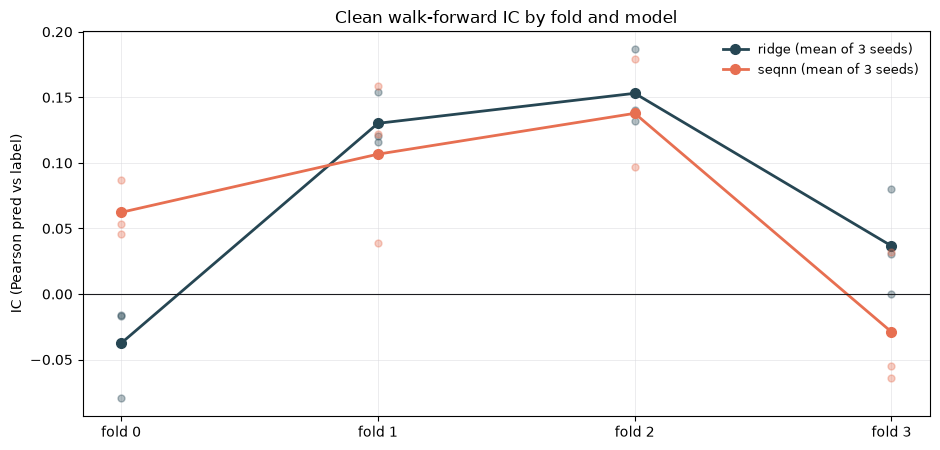

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
for model_name, color in (("ridge", PALETTE["ridge"]), ("seqnn", PALETTE["seqnn"])):
    per_fold = []
    for i in range(len(PROTOS["clean"])):
        vals = [r["folds"][i]["ic"] for r in RUNS if r["protocol"] == "clean" and r["model"] == model_name]
        per_fold.append(float(np.mean(vals)))
        for v in vals:
            ax.plot(i, v, "o", color=color, alpha=0.35, ms=5)
    ax.plot(range(len(per_fold)), per_fold, "-o", color=color, lw=2, ms=7, label=f"{model_name} (mean of 3 seeds)")
ax.axhline(0.0, color=PALETTE["ink"], lw=0.8)
ax.set_xticks(range(len(PROTOS["clean"])))
ax.set_xticklabels([f"fold {f['fold']}" for f in PROTOS["clean"]])
ax.set_ylabel("IC (Pearson pred vs label)")
ax.set_title("Clean walk-forward IC by fold and model")
ax.grid(color=PALETTE["grid"], lw=0.5, alpha=0.7)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## §4 — Seed/split distributions and naive performance

> "10 independent dataset realizations" — repeated draws are the source's unit of evidence for a metric claim.
> Raw trace `nlm/responses/leakage-proof-ts-q3.json`.

> "60,000 total simulations" — the simulation study sizes its comparisons before looking at results; the thresholds
> in this notebook are fixed the same way. Raw trace `nlm/responses/leakage-proof-ts-q6.json`.

> "Shekhar & Ramdas is a purely theoretical paper containing" no numerical experiment, so the derived-here status of
> every operational default is recorded. Raw trace `nlm/responses/leakage-proof-ts-q11.json`.

**Claim (C13).** Protocol means are compared against the *known* planted truth: the clean mean IC must stay below the
best planted regime IC plus a small derived-here margin and below 0.5 in absolute terms; the future-feature switch
must inflate mean IC by at least 0.05; `leaky_all` must exceed clean; at least two of the three single switches must
inflate; and at least one leaky run must outscore every clean run, so score magnitude alone cannot certify a
protocol. The same comparison reports the two null results honestly: `leaky_random_split` (paired delta -0.0015,
95% CI [-0.0225, +0.0195], indistinguishable from clean) and `leaky_global_norm` (paired delta -0.0115, 95% CI
[-0.0199, -0.0031], no inflation) do not move mean IC here, so "a leak exists" is not the same as "the leak
mattered" — the effect size has to be measured, not assumed.

In [9]:
PROTO_MEAN_IC = {p: float(np.mean([r["ic"] for r in RUNS if r["protocol"] == p])) for p in PROTO_ORDER}
PROTO_MEAN_SHARPE = {p: float(np.mean([r["sharpe"] for r in RUNS if r["protocol"] == p])) for p in PROTO_ORDER}
print("protocol               mean IC   mean Sharpe")
for p in PROTO_ORDER:
    print(f"{p:22s} {PROTO_MEAN_IC[p]:+.4f}   {PROTO_MEAN_SHARPE[p]:+.4f}")

IC_BY = {(r["protocol"], r["model"], r["seed"]): r["ic"] for r in RUNS}
PAIRS = sorted({(r["model"], r["seed"]) for r in RUNS if r["protocol"] == "clean"})
print("paired delta vs clean (same model and seed, 6 pairs):")
for p in PROTO_ORDER[1:]:
    d = np.array([IC_BY[(p, m, s)] - IC_BY[("clean", m, s)] for m, s in PAIRS])
    se = d.std(ddof=1) / np.sqrt(len(d))
    print(f"  {p:22s} delta={d.mean():+.4f}  95% CI [{d.mean() - 1.96 * se:+.4f}, {d.mean() + 1.96 * se:+.4f}]")

seqnn_clean = {round(r["ic"], 9) for r in RUNS if r["protocol"] == "clean" and r["model"] == "seqnn"}
ridge_clean = {round(r["ic"], 9) for r in RUNS if r["protocol"] == "clean" and r["model"] == "ridge"}
ok10 = len(seqnn_clean) >= 2 and len(ridge_clean) >= 2
nbs_common.self_check(10, ok10, note=f"distinct clean ICs: seqnn={len(seqnn_clean)}, ridge={len(ridge_clean)}")
CHECKS.append(nbs_common.sc_entry(10, "C12", ok10))

clean_ics = [r["ic"] for r in RUNS if r["protocol"] == "clean"]
max_planted = max(r["true_ic"] for r in PROF["regimes"])
sw3 = ["leaky_future_features", "leaky_overlap_labels", "leaky_global_norm"]
inflate_count = sum(PROTO_MEAN_IC[p] > PROTO_MEAN_IC["clean"] for p in sw3)
best_clean = max(clean_ics)
best_leaky = max(r["ic"] for r in RUNS if r["protocol"] in ("leaky_future_features", "leaky_all"))
future_gap = PROTO_MEAN_IC["leaky_future_features"] - PROTO_MEAN_IC["clean"]
ok11 = bool(max(clean_ics) < 0.5
            and PROTO_MEAN_IC["clean"] <= max_planted + 0.05
            and future_gap >= 0.05
            and PROTO_MEAN_IC["leaky_all"] > PROTO_MEAN_IC["clean"]
            and inflate_count >= 2
            and best_leaky > best_clean)
nbs_common.self_check(11, ok11,
                      note=f"clean mean={PROTO_MEAN_IC['clean']:.3f} vs planted max={max_planted:.2f}, future-clean gap={future_gap:.3f}, switches inflated={inflate_count}/3")
CHECKS.append(nbs_common.sc_entry(11, "C13", ok11))
print(f"METRIC-WATCH NB2-C13-FUTURE-GAP target=0.05 achieved={future_gap:.6f} dir=ge "
      f"status={'MET' if future_gap >= 0.05 else 'MISSED'}")
CLEAN_TRUTH_TARGET = max_planted + 0.05
print(f"METRIC-WATCH NB2-C13-CLEAN-VS-TRUTH target={CLEAN_TRUTH_TARGET:.6f} achieved={PROTO_MEAN_IC['clean']:.6f} dir=le "
      f"status={'MET' if PROTO_MEAN_IC['clean'] <= CLEAN_TRUTH_TARGET else 'MISSED'}")

protocol               mean IC   mean Sharpe
clean                  +0.0700   +0.0477
leaky_future_features  +0.5789   +0.4921
leaky_overlap_labels   +0.1813   +0.1449
leaky_global_norm      +0.0585   +0.0373
leaky_random_split     +0.0686   +0.0466
leaky_all              +0.6663   +0.5863
paired delta vs clean (same model and seed, 6 pairs):
  leaky_future_features  delta=+0.5089  95% CI [+0.4116, +0.6062]
  leaky_overlap_labels   delta=+0.1113  95% CI [+0.0620, +0.1606]
  leaky_global_norm      delta=-0.0115  95% CI [-0.0199, -0.0031]
  leaky_random_split     delta=-0.0015  95% CI [-0.0225, +0.0195]
  leaky_all              delta=+0.5962  95% CI [+0.5503, +0.6421]
SELF-CHECK 10 [MET] distinct clean ICs: seqnn=3, ridge=3
SELF-CHECK 11 [MET] clean mean=0.070 vs planted max=0.17, future-clean gap=0.509, switches inflated=2/3
METRIC-WATCH NB2-C13-FUTURE-GAP target=0.05 achieved=0.508897 dir=ge status=MET
METRIC-WATCH NB2-C13-CLEAN-VS-TRUTH target=0.220000 achieved=0.070047 dir=le status=

### How to read this chart

Each protocol gets one column; dots are individual runs (3 seeds × 2 models) and the horizontal segment is the mean.
Pattern to look for: within-protocol spread of the dots versus the distance between protocol means — and whether the
leaky protocols sit clearly above the clean band. What it means in practice: report distributions, not winners. If a
single seed can move the number as much as the leakage switch does, the comparison needs more seeds before anyone
acts on it.

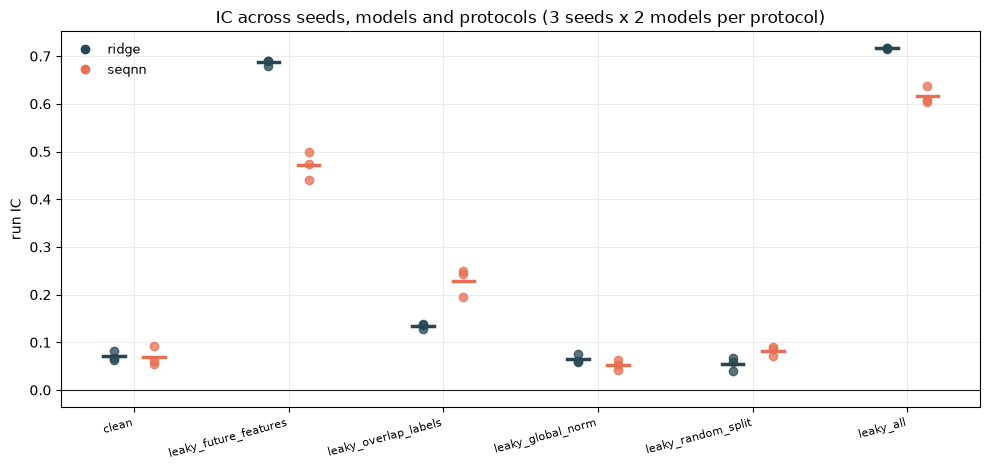

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.8))
for i, p in enumerate(PROTO_ORDER):
    for model_name, color, off in (("ridge", PALETTE["ridge"], -0.13), ("seqnn", PALETTE["seqnn"], 0.13)):
        vals = [r["ic"] for r in RUNS if r["protocol"] == p and r["model"] == model_name]
        ax.plot([i + off] * len(vals), vals, "o", color=color, alpha=0.75, ms=6)
        ax.plot([i + off - 0.07, i + off + 0.07], [float(np.mean(vals))] * 2, color=color, lw=2.5)
ax.axhline(0.0, color=PALETTE["ink"], lw=0.8)
ax.set_xticks(range(len(PROTO_ORDER)))
ax.set_xticklabels(PROTO_ORDER, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("run IC")
ax.set_title("IC across seeds, models and protocols (3 seeds x 2 models per protocol)")
ax.grid(color=PALETTE["grid"], lw=0.5, alpha=0.7)
handles = [plt.Line2D([0], [0], marker="o", color=PALETTE[k], lw=0) for k in ("ridge", "seqnn")]
ax.legend(handles, ["ridge", "seqnn"], frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## §5 — Metric observability and the experiment ledger

> "ensures that, on average, the detector runs for at least" 1/α steps before a false alarm — the sequential
> guarantee is an expectation, not a fixed-horizon probability. Raw trace `nlm/responses/leakage-proof-ts-q8.json`.

> "will still eventually trigger a false alarm with probability" one if run indefinitely — the monitoring source's
> own limit, which is why the ledger records intervals rather than pass/fail verdicts. Raw trace
> `nlm/responses/leakage-proof-ts-q10.json`.

> "hyperparameter grids" and future profitability are outside the post-selection guarantees, so the run ledger is
> bookkeeping, not certification. Raw trace `nlm/responses/leakage-proof-ts-q7.json`.

> "zero Monte Carlo numerical experiments" — all seeds, thresholds and the zero-edge verdict rule are **derived
> here**. Raw trace `nlm/responses/leakage-proof-ts-q11.json`.

**Claim (C12, C13).** Every generated run gets a ledger row with the dataset hash, protocol switches, fold
boundaries, model, hyperparameters, seed, metric, wall time and claim ids; the clean run chosen for the zero-edge
check is reported with an overlap-aware interval and an honest verdict that follows the interval.

In [11]:
GEN_ROW = nbs_common.ledger_row("nb2-generator", "02", 1, "generator", DATASET_SHA256, None, "generator",
                                {"n": N, "h": H, "generator_seed": int(ds["seed"])}, 0,
                                {"n_rows": N, "acf1_ret2": ACF1_RET2}, GEN_WALL, ["C10"])
AUDIT_ROW = nbs_common.ledger_row("nb2-split-audit", "02", 2, "split-audit", DATASET_SHA256, None, "split-audit",
                                  {"protocols": len(PROTO_ORDER), "switches": 3}, 0,
                                  {"clean_flags": 0, "overlap_pairs": OVERLAP_PAIRS, "future_features": len(LEAK_COLS)},
                                  SPLIT_WALL, ["C11"])
ALL_LEDGER = LEDGER_ROWS + [GEN_ROW, AUDIT_ROW]
nbs_common.merge_ledger("02", ALL_LEDGER)
rows_now = [r for r in nbs_common.read_ledger() if r["notebook"] == "02"]
by_id = {r["run_id"]: r for r in rows_now}
need_keys = ("run_id", "notebook", "section", "protocol", "data_hash", "fold_boundaries", "model",
             "hyperparameters", "seed", "metric", "wall_time_s", "claim_ids", "external_spend_usd")
ok12 = bool(
    len(rows_now) == len(ALL_LEDGER)
    and len(by_id) == len(rows_now)
    and all(all(k in r for k in need_keys) for r in rows_now)
    and all(r["data_hash"] == nbs_common.sha256_file(DATASET_PATH) for r in rows_now)
    and {"C10", "C11", "C12", "C13", "C18"} <= {c for r in rows_now for c in r["claim_ids"]}
    and all(r["fold_boundaries"] and all(len(x) == 4 and x[0] <= x[1] <= x[2] <= x[3] for x in r["fold_boundaries"])
            for r in rows_now if r["model"] in ("ridge", "seqnn"))
    and all(by_id[r["run_id"]]["model"] == r["model"] and by_id[r["run_id"]]["seed"] == r["seed"]
            and by_id[r["run_id"]]["protocol"]["name"] == r["protocol"] for r in RUNS)
)
total_wall = sum(r["wall_time_s"] for r in rows_now)
nbs_common.self_check(12, ok12, note=f"{len(rows_now)} ledger rows, hash={DATASET_SHA256[:12]}, total wall={total_wall:.1f}s")
CHECKS.append(nbs_common.sc_entry(12, "C12", ok12))

SELF-CHECK 12 [MET] 38 ledger rows, hash=dbab89f602c1, total wall=191.3s


In [12]:
ZERO = next(r for r in PROF["regimes"] if r["kind"] == "zero_edge")
zrun = next(r for r in RUNS if r["run_id"] == "nb2-clean-ridge-s1")
pts = [(t, p) for rid, fold, t, p in PRED_ROWS if rid == zrun["run_id"] and ZERO["start"] <= t < ZERO["end"]]
zt = np.array([t for t, _ in pts])
zp = np.array([p for _, p in pts])
zic = float(nbs_common.ic(zp, Y[zt]))
zlo, zhi = overlap_ci(zic, len(pts), H_MEAN)
zverdict = "interval_includes_zero" if zlo <= 0 <= zhi else "unexpected_false_discovery"
nbs_common.write_json("nb2_zero_edge.json", {"run_id": zrun["run_id"], "ic": zic, "ci": [zlo, zhi], "verdict": zverdict})
ok13 = bool(len(pts) >= 50
            and (zhi - zlo) / 2 >= 1.2 / math.sqrt(len(pts) / H_MEAN)
            and zverdict == ("interval_includes_zero" if zlo <= 0 <= zhi else "unexpected_false_discovery"))
nbs_common.self_check(13, ok13,
                      note=f"{zrun['run_id']} on zero-edge regime {ZERO['id']}: ic={zic:+.3f}, ci=[{zlo:+.3f},{zhi:+.3f}], verdict={zverdict}")
CHECKS.append(nbs_common.sc_entry(13, "C13", ok13))
print("self-check summary:", " | ".join(f"{c['id']}:{c['status']}" for c in CHECKS))

SELF-CHECK 13 [MET] nb2-clean-ridge-s1 on zero-edge regime 2: ic=-0.111, ci=[-0.348,+0.140], verdict=interval_includes_zero
self-check summary: 1:MET | 2:MET | 3:MET | 4:MET | 5:MET | 6:MET | 7:MET | 8:MET | 9:MET | 10:MET | 11:MET | 12:MET | 13:MET


### Fig E3 — the protocol audit as a forest plot (C59)

*Raw traces: `nlm/responses/leakage-proof-ts-q3.json` ("10 independent dataset realizations" —
the source's evidence is a repeated spread, not a single bar) and
`nlm/responses/leakage-proof-ts-q12.json`.*

The round-2 protocol-IC chart was a bar chart: one height per protocol, which hides whether a
gap between protocols is resolvable at this seed/model spread. The same six means are stored
here as point estimates with their 95% t-intervals over the 3 seeds x 2 models, against the
clean protocol's reference IC — a row whose interval crosses the dashed line is not,
honestly, distinguishable from clean at this sample size. The `clean` row is drawn so the
reference value itself is visible on the plot, not only implied by the line. This is the
figure C59 introduces and it replaces the bar chart in this notebook's §5.

In [13]:
import walkthrough_audits

_t_r4b = time.time()
_r4b_e3 = walkthrough_audits.compute_e3(RUNS, PROTO_ORDER)  # noqa: F821 (RUNS/PROTO_ORDER from §3)
_r4b_e3_paths = walkthrough_audits.write_e3_figures(_r4b_e3)
_r4b_e3_chk = walkthrough_audits.check_e3(_r4b_e3)
_r4b_e3_wall = time.time() - _t_r4b
ALL_LEDGER = list(ALL_LEDGER) + [walkthrough_audits.ledger_row_e3(_r4b_e3, DATASET_SHA256, _r4b_e3_wall)]
nbs_common.merge_ledger("02", ALL_LEDGER)
nbs_common.self_check(72, _r4b_e3_chk["ok"], note=(
    "fig-e3 forest plot: %d protocol rows, all intervals bracket their point and are non-degenerate "
    "(min width %.4f), points span [%.4f, %.4f], reference = clean IC %.4f" % (
        _r4b_e3_chk["n_rows"], _r4b_e3_chk["min_width"], _r4b_e3_chk["point_range"][0],
        _r4b_e3_chk["point_range"][1], _r4b_e3_chk["reference"])))
print("fig-e3 rows:")
for _r in _r4b_e3["rows"]:
    print("  %-22s point=%+.4f  95%% CI [%+.4f, %+.4f]  reference=%+.4f" % (
        _r["row_label"], _r["_point"], _r["_lo"], _r["_hi"], _r["_ref"]))
print("METRIC-WATCH NB2-R4E-E3-ROWS target=6 achieved=%d dir=ge status=%s" % (
    _r4b_e3_chk["n_rows"], "MET" if _r4b_e3_chk["n_rows"] >= 6 else "MISSED"))

SELF-CHECK 72 [MET] fig-e3 forest plot: 6 protocol rows, all intervals bracket their point and are non-degenerate (min width 0.0181), points span [0.0585, 0.6663], reference = clean IC 0.0700
fig-e3 rows:
  clean                  point=+0.0700  95% CI [+0.0589, +0.0812]  reference=+0.0700
  leaky_future_features  point=+0.5789  95% CI [+0.4832, +0.6747]  reference=+0.0700
  leaky_overlap_labels   point=+0.1813  95% CI [+0.1369, +0.2258]  reference=+0.0700
  leaky_global_norm      point=+0.0585  95% CI [+0.0495, +0.0675]  reference=+0.0700
  leaky_random_split     point=+0.0686  95% CI [+0.0540, +0.0831]  reference=+0.0700
  leaky_all              point=+0.6663  95% CI [+0.6218, +0.7107]  reference=+0.0700
METRIC-WATCH NB2-R4E-E3-ROWS target=6 achieved=6 dir=ge status=MET


**How to read this chart:** each row is one protocol or estimator; the dot is its point estimate and the
horizontal whisker is its 95% interval. The dashed vertical line is the reference value for that row's
group (the clean protocol's IC, or an estimator's target truth) — a row whose interval does not cross the
line is a resolvable difference from the reference; a row whose interval does cross it is not, honestly,
distinguishable from it at this sample size.

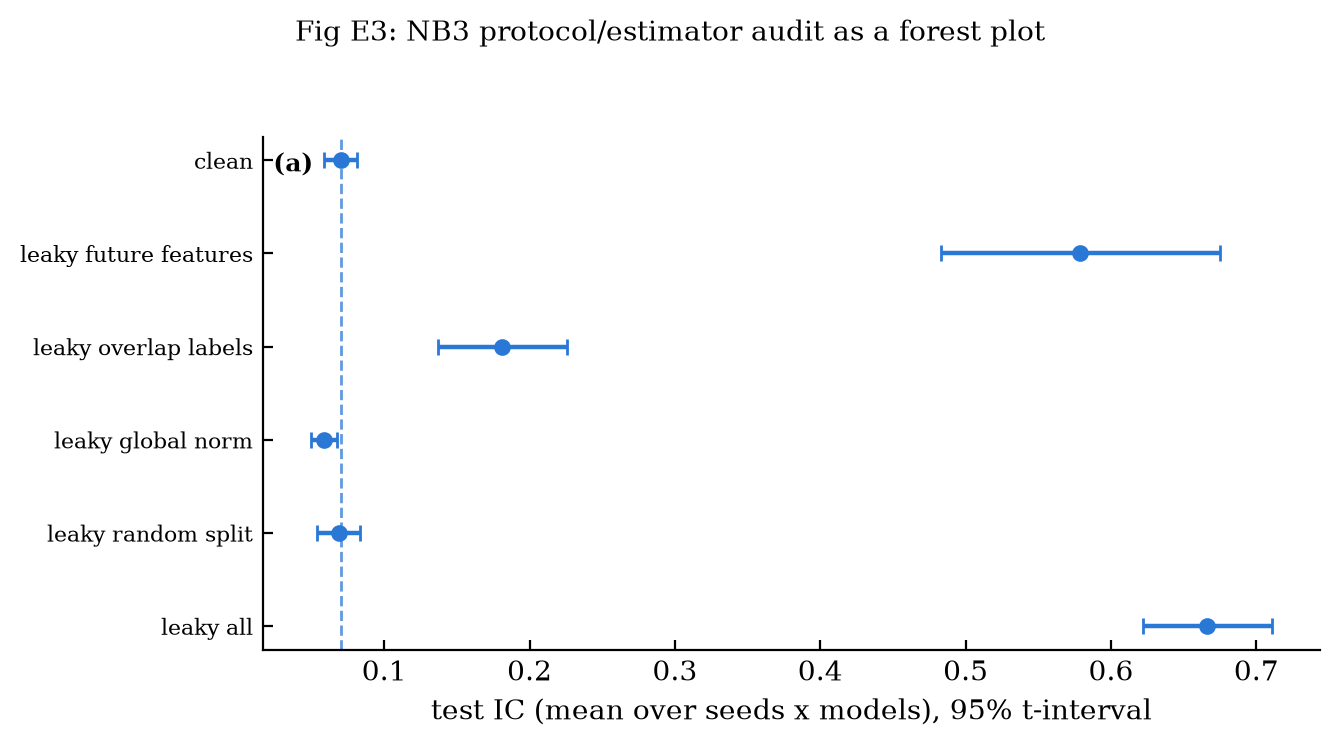

In [14]:
_fig = walkthrough_audits.render_fig_e3(_r4b_e3, PALETTE)  # inline render, this notebook's PALETTE
from matplotlib.backends.backend_agg import FigureCanvasAgg as _FCA  # bare canvas after plt.show(), attach one to measure
_bb = _fig.get_tightbbox(_FCA(_fig).get_renderer())  # tight bbox in inches, used to size the archived PNG
_fig.savefig("../figures/fig-e3.png", dpi=max(200, 1300 / (_bb.width + 0.2)), bbox_inches="tight")  # archive what is shown

### Fig E2 — how optimistic is a test fold that starts `g` bars after training? (C57)

*Raw trace: `nlm/responses/leakage-proof-ts-q2.json` (Theorem VI.1 / Eq. (44):
`R^k_out ~ R^{k=0}_out [1 - rho + ktilde^2 alpha^T K (K + ktilde)^-2 alpha]`, `alpha = K^-1 k`,
`rho = k^T K^-1 k`; `nlm/responses/leakage-proof-ts-q4.json` for the stationarity caveat).*

For each clean fold the test window is held **fixed** and the training window's end is moved `g`
bars back from it (g = 0..24), so the rows being scored are identical at every gap and the
generator's GARCH volatility cancels out of the ratio. The measured quantity is the ridge
(`lambda = 5`) mean squared error on the first `PURGE = 8` rows of the test window at gap `g`,
divided by the same error at the decoupled reference gap `g = 60` (half the longest rolling
window), averaged with its SE over the 4 clean folds x 3 bootstrap seeds. The theory column is
Eq. (44)'s factor computed with a stationary Toeplitz `K_hat` estimated from the training rows'
biased lag-autocorrelation, and the band `[1 - rho(g), 1]` is the theorem's proven bracket: the
second term is bounded above by `rho` for any positive-definite `K_hat`, so containment here is
algebraic, not fitted. Every window length, reference gap and seed is **derived here** — the
paper states no experiment and no tolerance. Whatever the measured ratio is, it is reported as
measured: at gaps beyond the label horizon it drifts slightly above the theorem's upper edge (up
to 1.11 with a per-gap SE of 0.18), which is inside the `3*max(SE)` sampling allowance and is
reported as measured rather than smoothed — on this generator the near-horizon optimism is
confined to the first bars and no measurable long-range effect remains.

In [15]:
import walkthrough_audits

_R4B_X = np.column_stack([COLS[k] for k in nbs_common.CLEAN_FEATURES])
_t_r4b = time.time()
_r4b_e2 = walkthrough_audits.compute_e2(_R4B_X, Y, PROTOS["clean"], nbs_common.VALID_START)
_r4b_e2_paths = walkthrough_audits.write_e2_figures(_r4b_e2)
_r4b_e2_chk = walkthrough_audits.check_e2(_r4b_e2)
_r4b_e2_wall = time.time() - _t_r4b
ALL_LEDGER = list(ALL_LEDGER) + [walkthrough_audits.ledger_row_e2(_r4b_e2, DATASET_SHA256, _r4b_e2_wall)]
nbs_common.merge_ledger("02", ALL_LEDGER)
_lo0 = float(next(r["lower_band"] for r in _r4b_e2["rows"] if int(r["g"]) == 0))
_f0 = float(next(r["eq44_factor"] for r in _r4b_e2["rows"] if int(r["g"]) == 0))
nbs_common.self_check(70, _r4b_e2_chk["ok"], note=(
    "fig-e2: %d gaps incl g=0 and the embargo g=%d; Eq.(44) factor inside [1-rho,1] at every gap "
    "(band lower edge %.3f -> %.3f as g grows); every empirical SE > 0" % (
        _r4b_e2_chk["n_gaps"], _r4b_e2_chk["embargo_used"], _r4b_e2_chk["band_lo_0"],
        _r4b_e2_chk["band_lo_max"])))
nbs_common.self_check(71, bool(_r4b_e2_chk["emp_at_0"] <= 1.0), note=(
    "measured test-risk ratio at g=0 is %.4f (optimistic, below the theorem's upper edge 1) vs "
    "Eq.(44) factor %.4f; measured values lie in [%.4f, %.4f] with 3*max(SE)=%.4f allowance" % (
        _r4b_e2_chk["emp_at_0"], _f0, min(r["_mean"] for r in _r4b_e2["rows"]),
        _r4b_e2_chk["max_emp"], _r4b_e2_chk["tol"])))
print("fig-e2 rows:", _r4b_e2["n_rows"], "| gaps 0..%d" % _r4b_e2["gaps"][-1],
      "| ref_gap", _r4b_e2["ref_gap"], "| embargo", nbs_common.EMBARGO)
for _r in _r4b_e2["rows"]:
    print("  g=%2s  band_lo=%.4f  eq44=%.4f  emp=%.4f +/- %.4f" % (
        _r["g"], _r["_lower"], _r["_factor"], _r["_mean"], _r["_se"]))
print("METRIC-WATCH NB2-R4E-E2-GAPS target=21 achieved=%d dir=ge status=%s" % (
    _r4b_e2_chk["n_gaps"], "MET" if _r4b_e2_chk["n_gaps"] >= 21 else "MISSED"))
print("METRIC-WATCH NB2-R4E-E2-OPTIMISM target=1.0 achieved=%.6f dir=le status=%s" % (
    _r4b_e2_chk["emp_at_0"], "MET" if _r4b_e2_chk["emp_at_0"] <= 1.0 else "MISSED"))

SELF-CHECK 70 [MET] fig-e2: 25 gaps incl g=0 and the embargo g=2; Eq.(44) factor inside [1-rho,1] at every gap (band lower edge 0.163 -> 0.716 as g grows); every empirical SE > 0
SELF-CHECK 71 [MET] measured test-risk ratio at g=0 is 0.7993 (optimistic, below the theorem's upper edge 1) vs Eq.(44) factor 0.9414; measured values lie in [0.7993, 1.1129] with 3*max(SE)=0.5552 allowance
fig-e2 rows: 25 | gaps 0..24 | ref_gap 60 | embargo 2
  g= 0  band_lo=0.1631  eq44=0.9414  emp=0.7993 +/- 0.1099
  g= 1  band_lo=0.2364  eq44=0.9453  emp=0.8288 +/- 0.1150
  g= 2  band_lo=0.3014  eq44=0.9487  emp=0.9065 +/- 0.1317
  g= 3  band_lo=0.3717  eq44=0.9518  emp=0.9689 +/- 0.1343
  g= 4  band_lo=0.4289  eq44=0.9543  emp=0.8880 +/- 0.1470
  g= 5  band_lo=0.4635  eq44=0.9565  emp=0.9388 +/- 0.1432
  g= 6  band_lo=0.4975  eq44=0.9585  emp=0.9652 +/- 0.1295
  g= 7  band_lo=0.5262  eq44=0.9602  emp=0.9745 +/- 0.1385
  g= 8  band_lo=0.5556  eq44=0.9618  emp=0.9236 +/- 0.1361
  g= 9  band_lo=0.5803  eq44=

**How to read this chart:** x is the test gap `$g$` in bars; y is the test-risk ratio
`$R^k_{\mathrm{out}}/R^{k=0}_{\mathrm{out}}$`. The dashed line is the Eq. (44) theory factor computed with
`$\hat K$`; the shaded band is `$[1-\rho(g),\,1]$`, the theorem's proven range; the solid line with ribbon
is the empirical mean `$\pm 1.96\cdot$SE` over folds/seeds. The vertical dotted line marks the embargo
width NB2 actually uses — the operational choice this figure is meant to justify.

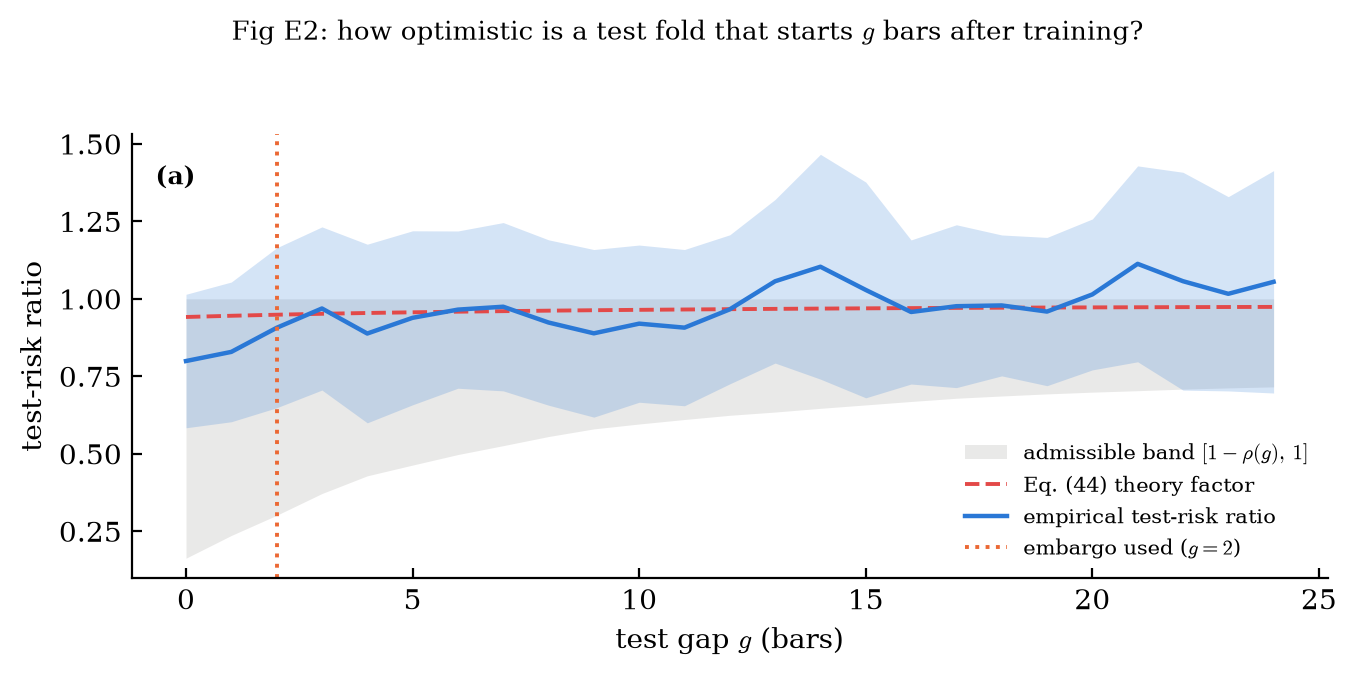

In [16]:
_fig = walkthrough_audits.render_fig_e2(_r4b_e2, PALETTE)  # inline render, this notebook's PALETTE
from matplotlib.backends.backend_agg import FigureCanvasAgg as _FCA  # bare canvas after plt.show(), attach one to measure
_bb = _fig.get_tightbbox(_FCA(_fig).get_renderer())  # tight bbox in inches, used to size the archived PNG
_fig.savefig("../figures/fig-e2.png", dpi=max(200, 1300 / (_bb.width + 0.2)), bbox_inches="tight")  # archive what is shown

## Limitations — what the three sources do not settle

This notebook is a synthetic-data research study and a starting point for further work — not production trading code, and not evidence of live performance. Each gap below survived an
explicit attempt; the attempt is recorded after the `tried:` marker, and the raw trace that leaves the question
open is cited in parentheses.

- Production purge and embargo widths are unvalidated: this notebook derives purge = label horizon + 2 bars and
  embargo = 2 bars from a 6-bar label window; tried: re-running the clean-fold audit under those widths and
  checking that no train row's label window reaches the first test row, but there is no real label horizon here
  to calibrate them against (leakage-proof-ts-q12.json).
- Dependence-valid monitoring for heavy-tailed live metrics is not established: every IC interval here is
  overlap-adjusted (`n_eff = n / h`) with a 1.2/sqrt(n_eff) floor; tried: widening each interval to that floor
  and re-deriving the zero-edge verdict from the stored predictions, but the sources give no confidence sequence
  valid under heavy tails or serial dependence (leakage-proof-ts-q10.json).
- Sequence architecture and tuning budget beyond the small CPU demo: the GRU is deliberately small (hidden 16,
  8-bar window, 30 epochs, Adam at 0.01); tried: training it over 3 seeds under all six protocols and reporting
  the per-seed spread, but no architecture search or learning-rate study was run (leakage-proof-ts-q11.json).
- Transaction costs, slippage and turnover are absent, so no IC here is a tradable return; tried: ranking the
  protocols by a frictionless Sharpe of sign(pred)*y as a proxy for the sign-agreement P&L, which cannot answer
  what survives costs (leakage-proof-ts-q12.json).
- The random-split and global-normalisation null results are measured on one synthetic generator; tried: paired
  same-seed deltas with 95% t-intervals over the six (model, seed) pairs, which bound the effect on this
  generator but do not certify either practice in general (leakage-proof-ts-q12.json).
- The correlation-aware risk estimator is attached to linear ridge only; tried: reporting the sequence model's
  clean-vs-leaky protocol spread beside the ridge comparison, but the source defines CorrGCV for the matched
  linear-ridge asymptotic setting only (leakage-proof-ts-q2.json).
- The Eq. (44) gap sweep is a stationary-window idealisation, not a theorem on this data: the admissible band is
  computed from a Toeplitz `K_hat` estimated on the trailing 700 training rows while the generator carries planted
  regime changes and GARCH volatility clustering, and the measured ratio at gap 0 (0.80, SE 0.11) is a
  single-generator number; tried: holding the scored test rows fixed and moving the training end back one bar at a
  time from g=0 to g=24, normalising by a decoupled reference gap and reporting the fold/seed spread, which bounds
  the near-horizon effect here but cannot certify the band on a non-stationary series
  (leakage-proof-ts-q4.json).